# Geospatial Data Science - EEPS 440/460

# Lecture 7

# Intro to statistics II


### Note: 
Update your job submission script (jupyter-smp.slurm) with the new docker (which now includes zarr)

Replace: *envspatialdata.sif* 

For:     *envspatialdata**2**.sif*

## Expectation (Discrete random variable)

$$E[X] = \sum_{i=1}^nx_ip(x_i) = \mu$$

Think of expectation as the population mean ($\mu = E[X]$). 

$p_i$ is the probability mass function.


## Expectation (Dice example)

The population of potential rolls is $x_i \in \{1,2,3,4,5,6\}$.

Thus the expected value (or population mean) is $\mu = \left(\frac{1+2+3+4+5+6}{6} = 21/6 = 3.5\right)$


## Sample mean vs population mean (i.e., expected value)

Sample mean:
$$\hat{\mu} = \frac{1}{n}\sum_{i=1}^nx_i$$
Assume we roll the dice 3 times and we get *1, 3, 4*. Then our sample mean would be $\hat{\mu} = 8/6$. 

Thus clearly $\hat{\mu} \neq \mu$ ($21/6 \neq 8/6$) and thus it is only an approximation.

## Arithmetic mean: Unbiased mean estimate

To ensure we have an unbiased estimator, then we want:

$$E[\hat{\mu}] = \mu$$

Naive example with 2 samples that cover the population:

$$\hat{\mu}_1 = \frac{1+3+4}{3} = 8/3$$
$$\hat{\mu}_2 = \frac{2+5+6}{3} = 13/3$$
$$\mu = E[\hat{\mu}] = 8/6 + 13/6 = 21/6 = 3.5$$

## Expectation (Continuous random variable)

$$E[X] = \int_{-\infty}^{\infty}xf(x)dx = \mu$$

Where $f(x)$ is our probability density function (pdf) for $X$.


## Expectation: Measure of central tendency

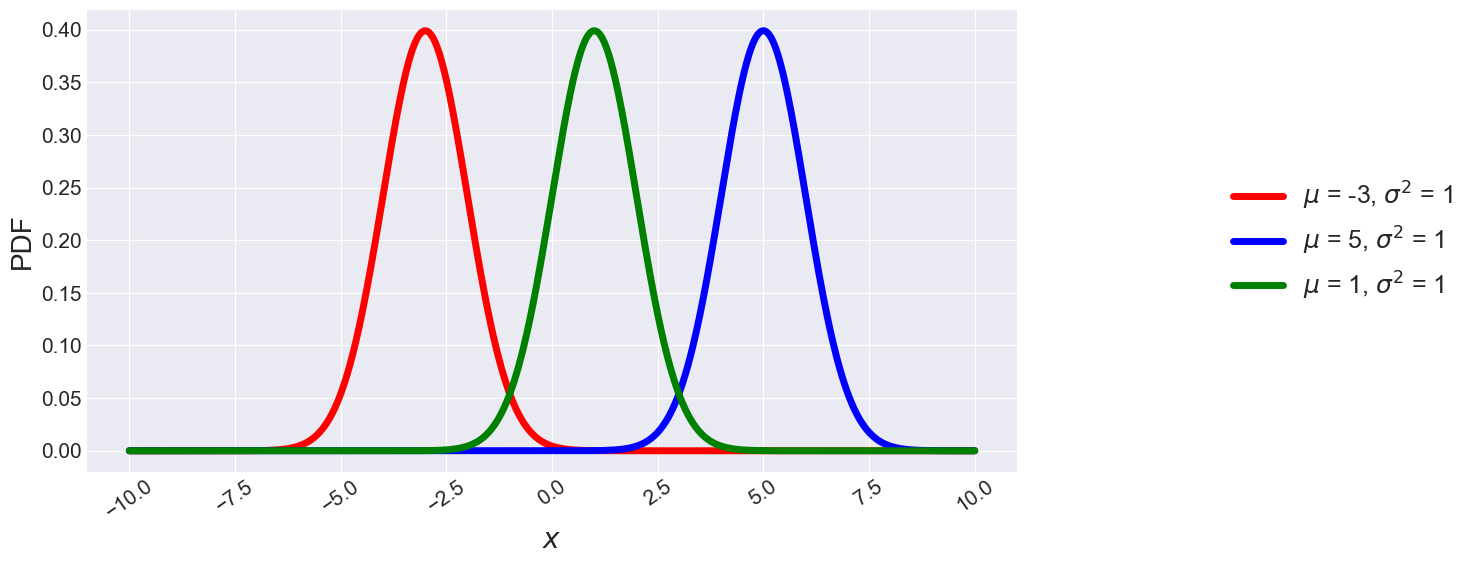

In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-darkgrid') 
%matplotlib inline
import scipy.stats
# create a an linear x array with 1000 elements
x = np.linspace(-10,10,1000)
plt.figure(figsize=(12,6))
#Plot the pdf of a normal distribution for different mu with standard deviation 1
plt.plot(x,scipy.stats.norm.pdf(x,-3,1),'r-', lw=5)
plt.plot(x,scipy.stats.norm.pdf(x,5,1),'b-', lw=5)
plt.plot(x,scipy.stats.norm.pdf(x,1,1),'g-', lw=5)
plt.xlabel(r'$x$',fontsize=20)
plt.ylabel('PDF',fontsize=20)
plt.xticks(fontsize=15,rotation=35)
plt.yticks(fontsize=15)
plt.grid('on')
plt.legend([r'$\mu$ = -3, $\sigma^2$ = 1',r'$\mu$ = 5, $\sigma^2$ = 1',r'$\mu$ = 1, $\sigma^2$ = 1'],
           fontsize=18, bbox_to_anchor=(1.1, 0.25, 0.5, 0.5),loc=10)
plt.grid('on')
plt.show()

## Central tendency: Other measures


**Geometric mean**:

$$\bar{x}_G = \left(\prod_{i=1}^n{x_i}\right)^{1/n}$$

**Harmonic mean**

$$\bar{x}_H = \left(\frac{\sum_i^n x_i^{-1}}{n}\right)^{-1}$$

**Median**

$$\text{~50th percentile}$$

# Variance: Measure of spread

$$\sigma^2 = \text{Var}[X] = E[\left(X - \mu_X\right)^2] = E[X^2] - E[X]^2$$



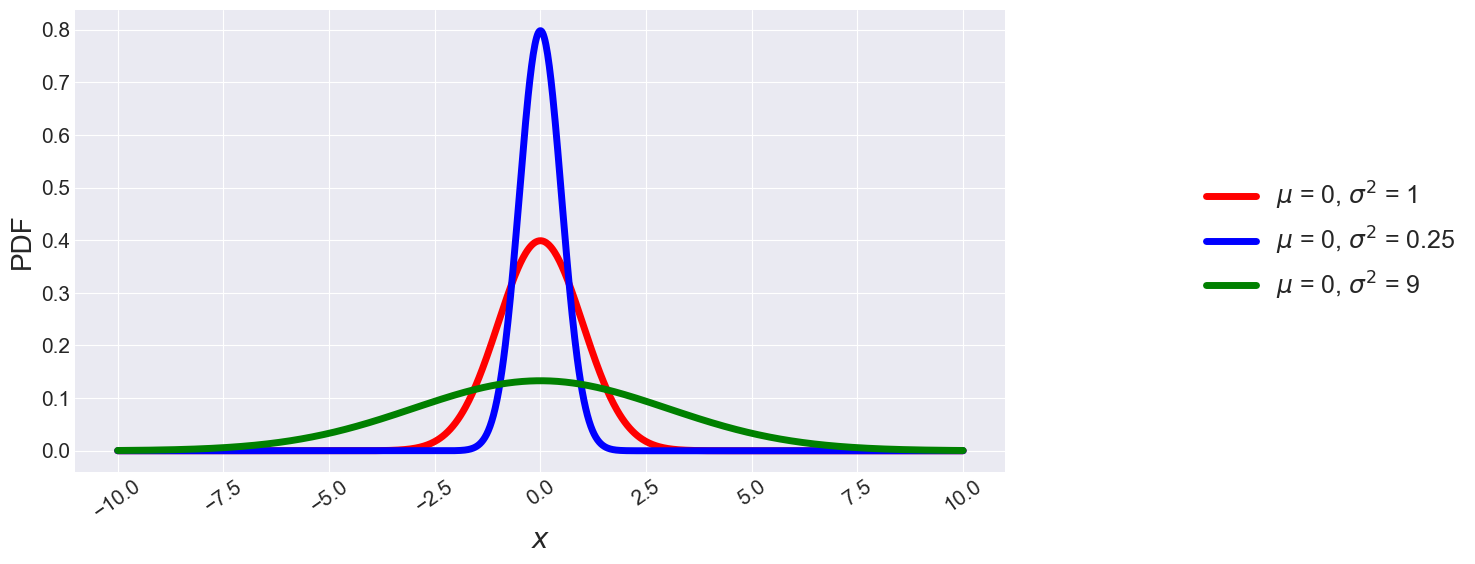

In [2]:
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-darkgrid')  
%matplotlib inline
import scipy.stats
x = np.linspace(-10,10,1000)
plt.figure(figsize=(12,6))
#Plot the pdf
plt.plot(x,scipy.stats.norm.pdf(x,0,1),'r-', lw=5)
plt.plot(x,scipy.stats.norm.pdf(x,0,0.5),'b-', lw=5)
plt.plot(x,scipy.stats.norm.pdf(x,0,3),'g-', lw=5)
plt.xlabel(r'$x$',fontsize=20)
plt.ylabel('PDF',fontsize=20)
plt.xticks(fontsize=15,rotation=35)
plt.yticks(fontsize=15)
plt.grid('on')
plt.legend([r'$\mu$ = 0, $\sigma^2$ = 1',r'$\mu$ = 0, $\sigma^2$ = 0.25',r'$\mu$ = 0, $\sigma^2$ = 9'],
           fontsize=18, bbox_to_anchor=(1.1, 0.25, 0.5, 0.5),loc=10)
plt.grid('on')
plt.show()

## Variance: Discrete vs. Continuous

Discrete: $$\text{Var}[X] = \sum_{i=1}^np(x_i)(x_i-\mu)^2$$

Continuous: $$\text{Var}[X] = \int_{-\infty}^{\infty}f(x)(x-\mu)^2dx$$


## Standard deviation

$$\sigma = \sqrt{\text{Var}[X]}$$

## Coefficient of variation

$$C_v = \frac{\sigma}{\mu}$$

## Sample variance

Sample variance: $$s^2 = \frac{1}{n}\sum_{i=1}^n(x_i-\hat{\mu})^2 \approx \sigma^2$$

Unbiased sample variance: $$s_{ub}^2 = \frac{1}{n-1}\sum_{i=1}^n(x_i-\hat{\mu})^2$$

## Other measures of spread

**Median absolute deviation**

$$m = \frac{1}{n-1}\sum_{i=1}^n\left|x_i - 50^{\text{th}\,\text{pct}}\right|$$

**Interquartile range**

$$\text{IQR} = 75^{\text{th}\,\text{pct}} - 25^{\text{th}\,\text{pct}}$$

# Let's move now towards the bivariate problem

## Covariance

Measure of the joint variability of random variables $X$ and $Y$.

$$\text{Cov}(X,Y) = E[\left(X - \mu_X\right)\left(Y - \mu_Y\right)] = E[XY] - \mu_X\mu_Y$$

Note that the variance is simply the covariance of $X$ with itself.

$$\text{Cov}(X,X) = \text{Var}(X,X) = E[\left(X - \mu_X\right)^2] = E[X^2] - E[X]^2$$

## Independence

If two random variables are independent, then:

$$\text{Cov}(X,Y) = 0$$

However, the converse is not always true.

## Sample covariance 

The sample covariance is given by:

$$\text{Cov}(X,Y) = \frac{1}{n}\sum_{i=1}^n(x_i - \hat{\mu}_X
)(y_i - \hat{\mu}_Y)$$

## Let's look at an example...

In [ ]:
import netCDF4 as nc    
import datetime
sites = {'seattle':{'lat':47.6062,'lon':-122.3321},
         'paris':{'lat':48.8566,'lon':2.3522},
         'santiago':{'lat':-33.4489,'lon':-70.6693}}
file = '/scratch/eeps440/data/era-interim/era_interim_monthly_197901_201512_upscaled.nc'
fp = nc.Dataset(file)
lats = fp['lat'][:]
lons = fp['lon'][:]
times = fp['time']
for site in sites:
    lat = sites[site]['lat']
    lon = sites[site]['lon']
    if lon < 0:lon = 360 + lon
    sites[site]['ilat'] = int(np.argmin(np.abs(lats - lat)))
    sites[site]['ilon'] = int(np.argmin(np.abs(lons - lon)))
var = 't2m'
#Iterate through all the sites
for site in sites:
    #Extract the data for the given site
    ilat = sites[site]['ilat']
    ilon = sites[site]['ilon']
    sites[site][var] = fp[var][:,ilat,ilon]
#Convert the dates to a datetime array
dates = nc.num2date(times[:],units=times.units,calendar=times.calendar,only_use_cftime_datetimes=False)

## Going back to our three city example

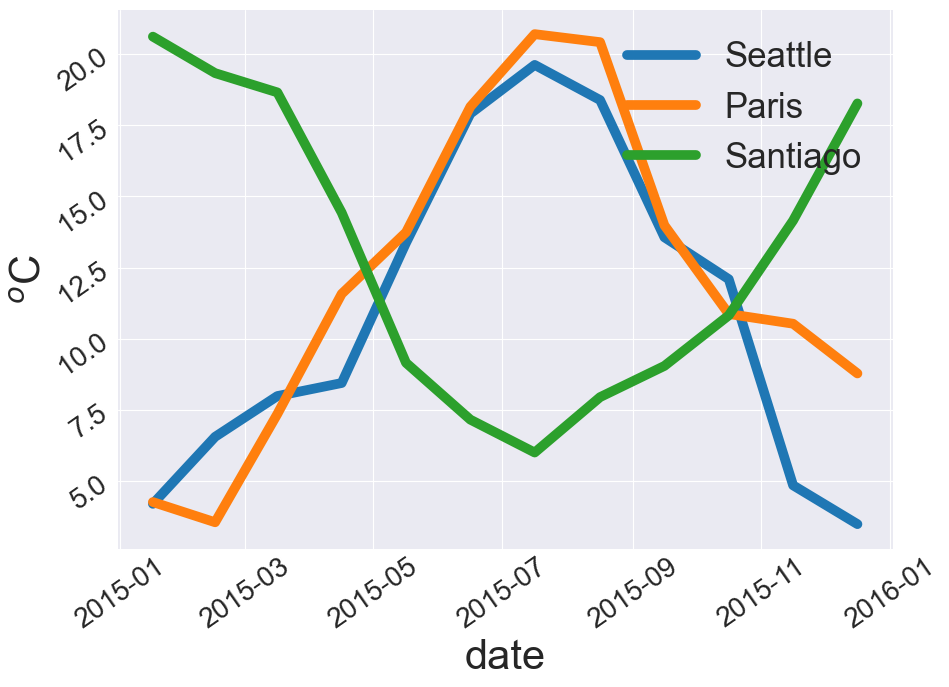

In [4]:
#Calculate the Boolean mask for dates within 2015
m = (dates >= datetime.datetime(2015,1,1)) & (dates <= datetime.datetime(2015,12,31))

#Assemble the subsetted dates array
dates_subset = dates[m]

plt.figure(figsize=(10,7))
plt.plot(dates_subset,sites['seattle']['t2m'][m],lw=7)
plt.plot(dates_subset,sites['paris']['t2m'][m],lw=7)
plt.plot(dates_subset,sites['santiago']['t2m'][m],lw=7)
plt.xticks(fontsize=20,rotation=35)
plt.yticks(fontsize=20,rotation=35)
plt.xlabel('date',fontsize=30)
plt.ylabel(r'$^o$C',fontsize=30)
plt.grid('on')
plt.legend(['Seattle','Paris','Santiago'],fontsize=25)
plt.show()

## Covariance between each time series

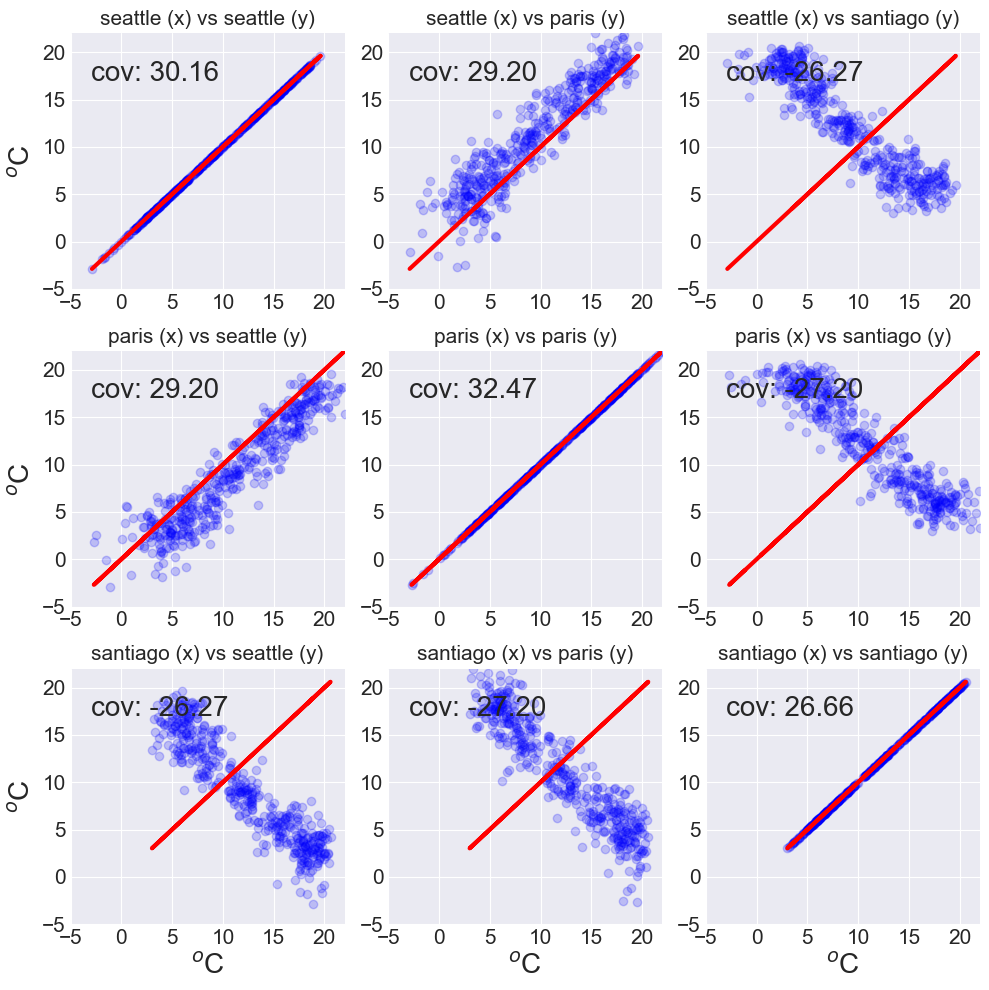

In [5]:
fig = plt.figure(figsize=(10,10))
i = 0
for site1 in sites:
    for site2 in sites:
        i = i + 1
        plt.subplot(3,3,i)
        plt.plot(sites[site1]['t2m'],sites[site2]['t2m'],'bo',alpha=0.2)
        plt.plot(sites[site1]['t2m'],sites[site1]['t2m'],'r',lw=3)
        plt.xticks(fontsize=15)
        plt.yticks(fontsize=15)
        plt.xlim([-5,22])
        plt.ylim([-5,22])
        plt.title('%s (x) vs %s (y)' % (site1,site2),fontsize=15)
        if i in [7,8,9]:plt.xlabel(r'$^o$C',fontsize=20)
        if i in [1,4,7]:plt.ylabel(r'$^o$C',fontsize=20)
        plt.text(-3,17,'cov: %.2f' % np.cov(sites[site1]['t2m'],sites[site2]['t2m'])[0,1],fontsize=20)
fig.tight_layout()
plt.show()

* Anyone can guess what is the variance of the temperature time series of Santiago?
* How is it possible that the covariance of Seattle vs Paris is higher than Santiago vs. Santiago?

## Pearson correlation coefficient

The Pearson correlation coefficient is simply a normalized covariance. 

$$\rho = \frac{\text{cov}(X,Y)}{\sqrt{\text{var}(X)}\sqrt{\text{var}(Y)}} = \frac{\text{cov}(X,Y)}{\sigma_X\sigma_Y}$$

Where $\sigma_X$ and $\sigma_Y$ are the standard deviation of $X$ and $Y$ respectively.



## Sample correlation coefficient 

The sample correlation coefficient can then be calculated as:

$$r = \frac{\sum_{i=1}^n(x_i - \bar{x})(y_i - \bar{y})}{\sqrt{{\sum_{i=1}^n(x_i - \bar{x})^2}}\sqrt{{\sum_{i=1}^n(y_i - \bar{y})^2}}} \approx \rho$$


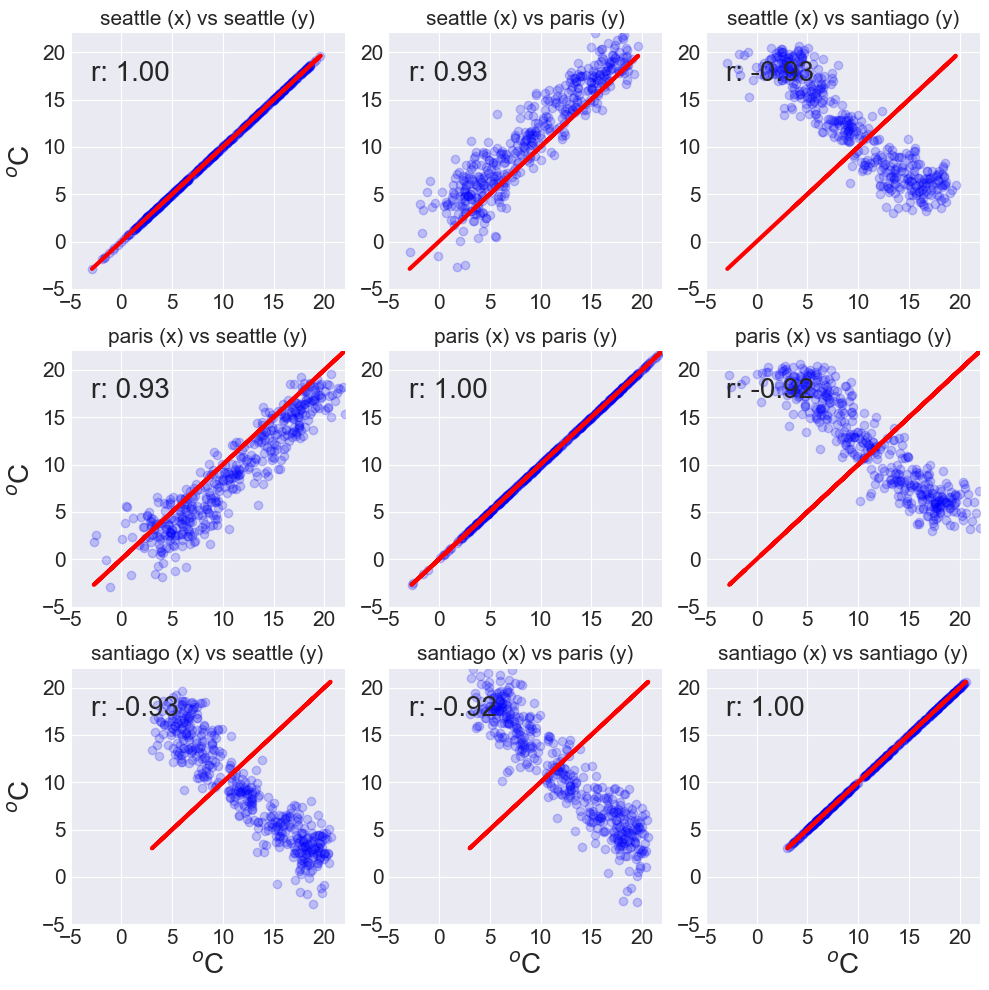

In [6]:
fig = plt.figure(figsize=(10,10))
i = 0
for site1 in sites:
    for site2 in sites:
        i = i + 1
        plt.subplot(3,3,i)
        plt.plot(sites[site1]['t2m'],sites[site2]['t2m'],'bo',alpha=0.2)
        plt.plot(sites[site1]['t2m'],sites[site1]['t2m'],'r',lw=3)
        plt.xticks(fontsize=15)
        plt.yticks(fontsize=15)
        plt.xlim([-5,22])
        plt.ylim([-5,22])
        plt.title('%s (x) vs %s (y)' % (site1,site2),fontsize=15)
        if i in [7,8,9]:plt.xlabel(r'$^o$C',fontsize=20)
        if i in [1,4,7]:plt.ylabel(r'$^o$C',fontsize=20)
        #plt.text(-3,17,'cov: %.2f' % np.cov(sites[site1]['t2m'],sites[site2]['t2m'])[0,1]/(np.std(sites[site1]['t2m'])*np.std(sites[site2]['t2m'])),fontsize=20)
        plt.text(-3,17,'r: %.2f' % np.corrcoef(sites[site1]['t2m'],sites[site2]['t2m'])[0,1],fontsize=20)
fig.tight_layout()
plt.show()

## Properties of expectation


* $E[X+Y] = E[X] + E[Y]$
* $E[aX + b] = aE[X] + b$
* $E[XY] = E[X]E[Y]$ if and only if X and Y are independent.


## Properties of variance

* $\text{Var}(X) \geq 0$
* $\text{Var}(a) = 0$
* $\text{Var}(a + X) = \text{Var}(X)$
* $\text{Var}(aX) = a^2\text{Var}(X)$
* $\text{Var}(aX + bY) = a^2\text{Var}(X) + b^2\text{Var}(Y) + 2ab\text{Cov}(X,Y)$

## Properties of covariance

* $\text{Cov}(X,a) = 0$
* $\text{Cov}(X,X) = \text{Var}(X)$
* $\text{Cov}(X,Y) = \text{Cov}(Y,X)$
* $\text{Cov}(aX,bY) = ab\text{Cov}(X,Y)$
* $\text{Cov}(a + X,b + Y) = \text{Cov}(X,Y)$


# We are now ready to go to n-dimensions

## Covariance matrix

$$\mathbf{\Sigma} = \begin{bmatrix}
\sigma^2_{X_1}&\cdots&\text{cov}(X_1,X_n)\\
\vdots&\ddots&\vdots\\
\text{cov}(X_n,X_1)&\cdots&\sigma^2_{X_n}\\
\end{bmatrix}$$

This is the population covariance matrix. We estimate the sample covariance matrix $\mathbf{Q}$ from data.


## Covariance matrix example

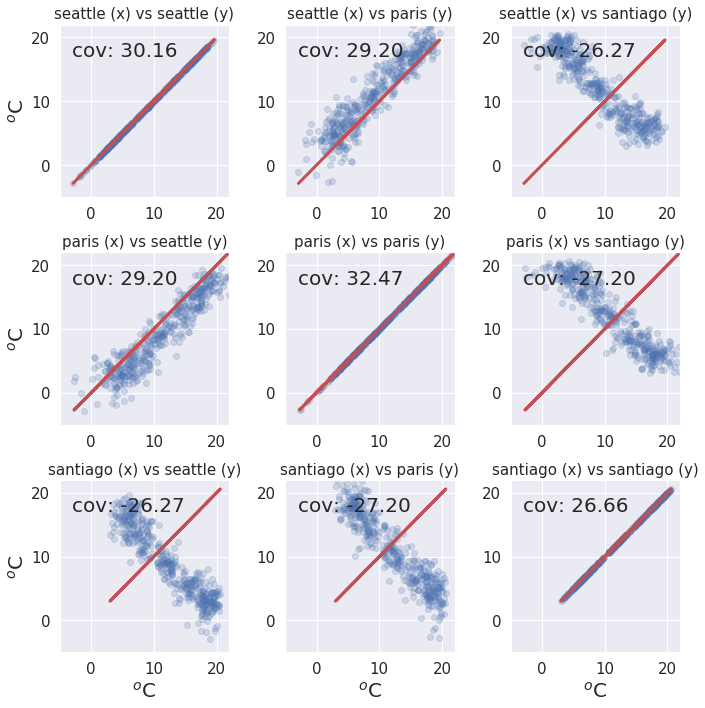

## Correlation matrix

$$\mathbf{\rho} = \begin{bmatrix}
1&\cdots&\frac{\text{cov}(X_1,X_n)}{\sigma_{X_1}\sigma_{X_n}}\\
\vdots&\ddots&\vdots\\
\frac{\text{cov}(X_n,X_1)}{\sigma_{X_n}\sigma_{X_1}}&\cdots&1\\
\end{bmatrix}$$


## Correlation matrix example

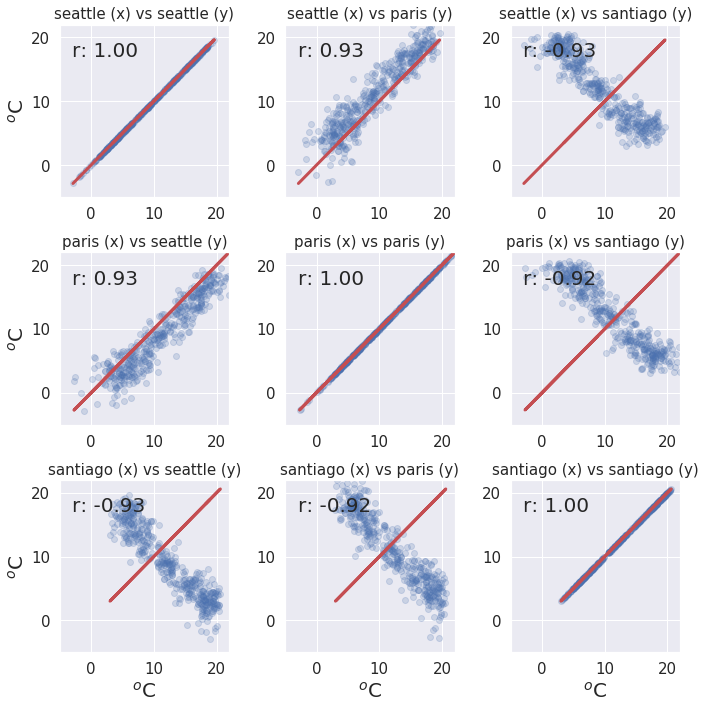

# Autocorrelation

The prefix "auto" in autocorrelation denotes correlation of a variable with itself. The temporal autocorrelation indicates the correlation of a variable with its own future and past values. Autocorrelations are generally computed using the Pearson correlation coefficient.

Let's look at the autocorrelation of simulated monthly soil temperature in Houston, TX from the NLDAS database

In [ ]:
#Import the corresponding libraries
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import netCDF4 as nc
import datetime
#Open access to the files and bring in the dates
file = '/scratch/eeps440/data/NLDASv2/NLDAS_NOAH0125_M.002.nc'
fp = nc.Dataset(file)
dates = nc.num2date(fp['time'][:],units=fp['time'].units,calendar='standard')
tmp = []
for date in dates:
    tmp.append(datetime.datetime(date.year,date.month,1))
dates = np.array(tmp)

In [8]:
#Let's extract the monthly time series for Houston
lat = 29.7171
lon = -95.4041 
lats = fp['lat'][:]
lons = fp['lon'][:]
ilat = np.argmin(np.abs(lats - lat))
ilon = np.argmin(np.abs(lons - lon))
m = (dates >= datetime.datetime(1979,1,1)) & (dates <= datetime.datetime(2018,12,31))
tsoil0_10cm = fp['tsoil0_10cm'][m,ilat,ilon]

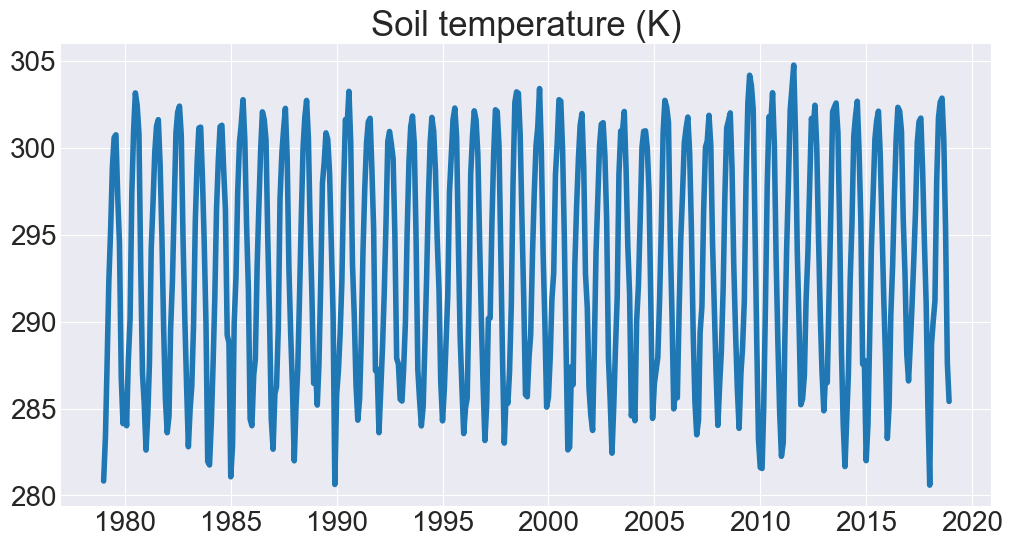

In [9]:
plt.figure(figsize=(12,6))
plt.plot(dates[m],tsoil0_10cm,lw=4)
plt.title('Soil temperature (K)',fontsize=25)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.show()

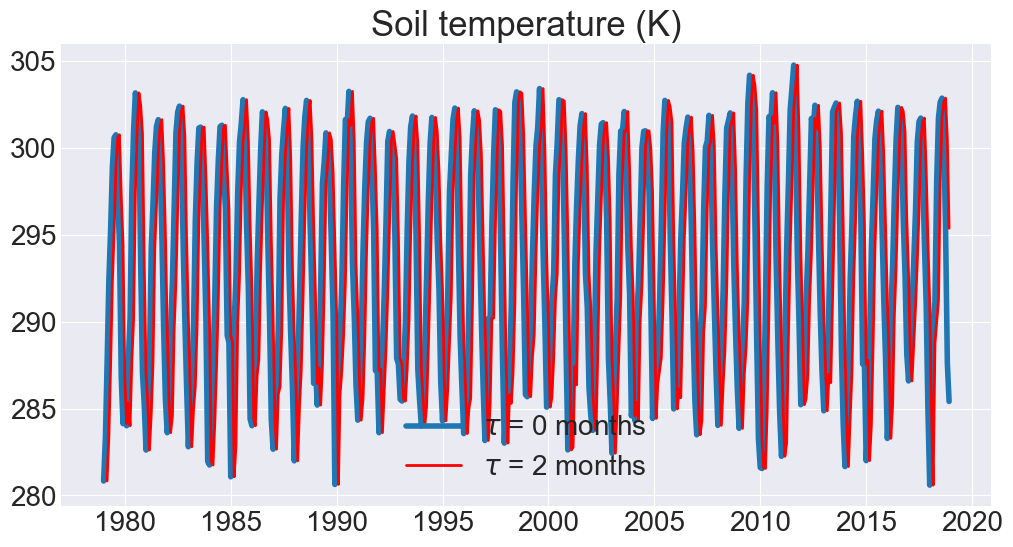

In [10]:
#Let's overlay the same time series but shifted two months later (time delay tau of two months)
plt.figure(figsize=(12,6))
plt.plot(dates[m],tsoil0_10cm,lw=4)
plt.plot(dates[m][2:],tsoil0_10cm[:-2],'r',lw=2)
plt.title('Soil temperature (K)',fontsize=25)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.legend([r'$\tau$ = 0 months',r'$\tau$ = 2 months'],fontsize=20)
plt.show()

Let's compute the serial correlation at multiple time delays and save the results

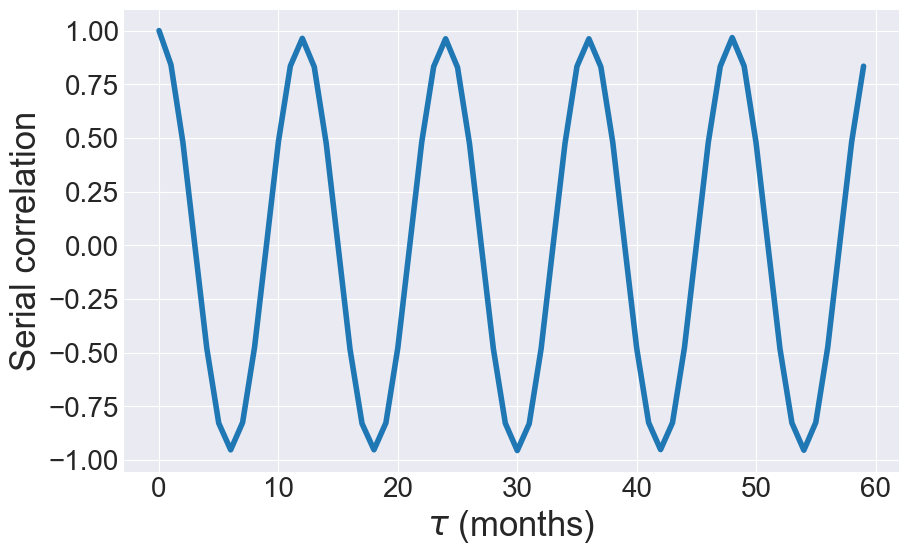

In [11]:
import scipy.stats
taus = np.arange(0,5*12) #months
vals = []
for tau in taus:
    if tau == 0:
        val = 1.0
    else: 
        val = scipy.stats.pearsonr(tsoil0_10cm[:-tau],tsoil0_10cm[tau:])[0]
    vals.append(val)
plt.figure(figsize=(10,6))
plt.plot(taus,vals,lw=4)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.ylabel('Serial correlation',fontsize=25)
plt.xlabel(r'$\tau$ (months)',fontsize=25)
plt.show()

Let's compute the 1 month delay ($\tau$ = 1 month) serial correlation for soil temperature across the entire NLDAS domain.

In [12]:
tsoil0_10cm_conus = np.ma.getdata(fp['tsoil0_10cm'][m,:,:])

In [13]:
import scipy.stats

def compute_serial_correlation(data,tau):
    output = np.zeros((data.shape[1],data.shape[2]))
    output[:] = -9999.0
    for i in range(data.shape[1]):
        for j in range(data.shape[2]):
            if data[0,i,j] == -999000000.0:
                continue
            output[i,j] = scipy.stats.pearsonr(data[tau:,i,j],data[:-tau,i,j])[0]
    return output

conus_tsoil_tau1 = compute_serial_correlation(tsoil0_10cm_conus,1)

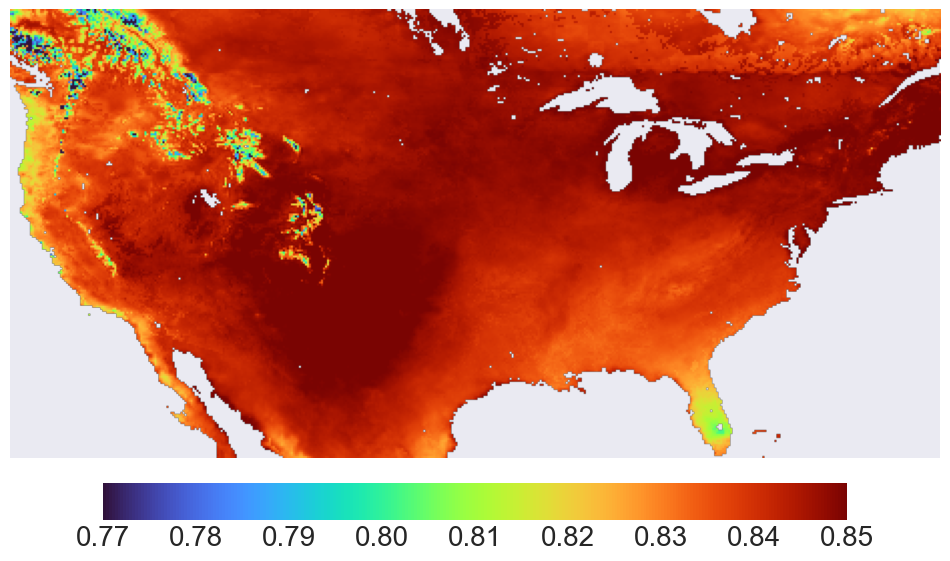

In [14]:
#Mask out -9999 values
conus_tsoil_tau1 = np.ma.masked_array(conus_tsoil_tau1,conus_tsoil_tau1==-9999)
plt.figure(figsize=(12,8))
plt.imshow(np.flipud(conus_tsoil_tau1),cmap=plt.get_cmap('turbo'),vmin=0.77,vmax=0.85)
cb = plt.colorbar(orientation='horizontal',shrink=0.8,pad=0.04)
cb.ax.tick_params(labelsize=20)
plt.xticks([])
plt.yticks([])
plt.show()

## Correlation between distinct locations

In [15]:
#Let's extract the monthly time series for Houston, TX and Austin, TX
lat_houston = 29.7171
lon_houston = -95.4041
lat_austin = 30.2672
lon_austin = -97.7431
lats = fp['lat'][:]
lons = fp['lon'][:]
ilat_houston = np.argmin(np.abs(lats - lat_houston))
ilon_houston = np.argmin(np.abs(lons - lon_houston))
ilat_austin = np.argmin(np.abs(lats - lat_austin))
ilon_austin = np.argmin(np.abs(lons - lon_austin))
m = (dates >= datetime.datetime(1979,1,1)) & (dates <= datetime.datetime(2018,12,31))
tsoil0_10cm_houston = fp['tsoil0_10cm'][m,ilat_houston,ilon_houston]
tsoil0_10cm_austin = fp['tsoil0_10cm'][m,ilat_austin,ilon_austin]

In [16]:
#Let's upscale to annual time step
tsoil0_10cm_houston_annual = []
tsoil0_10cm_austin_annual = []
imin = 0
imax = 12
for year in range(1979,2019):
    tsoil0_10cm_houston_annual.append(np.mean(tsoil0_10cm_houston[imin:imax]))
    tsoil0_10cm_austin_annual.append(np.mean(tsoil0_10cm_austin[imin:imax]))
    imin = imin + 12
    imax = imax + 12
tsoil0_10cm_houston_annual = np.array(tsoil0_10cm_houston_annual)
tsoil0_10cm_austin_annual = np.array(tsoil0_10cm_austin_annual)

Linear correlation: 0.94


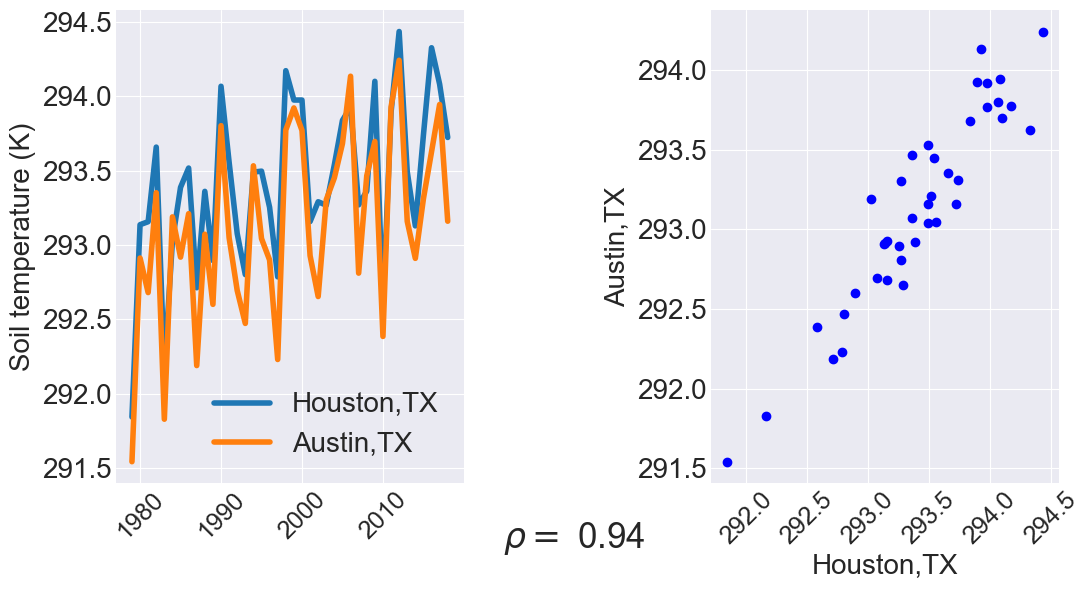

In [17]:
#Make some plots
plt.figure(figsize=(11,6))
plt.subplot(121)
plt.plot(np.arange(1979,2019),tsoil0_10cm_houston_annual,lw=4)
plt.plot(np.arange(1979,2019),tsoil0_10cm_austin_annual,lw=4)
plt.xticks(fontsize=18,rotation=45)
plt.yticks(fontsize=20)
plt.ylabel('Soil temperature (K)',fontsize=20)
plt.legend(['Houston,TX','Austin,TX'],fontsize=20)
plt.subplot(122)
plt.plot(tsoil0_10cm_houston_annual,tsoil0_10cm_austin_annual,'bo')
val = scipy.stats.pearsonr(tsoil0_10cm_houston_annual,tsoil0_10cm_austin_annual)[0]
print('Linear correlation: %.2f' %val)
plt.text(290,291,r'$\rho = $ %.2f' % val,fontsize=25)
plt.xticks(fontsize=18,rotation=45)
plt.yticks(fontsize=20)
plt.xlabel('Houston,TX',fontsize=20)
plt.ylabel('Austin,TX',fontsize=20)
plt.tight_layout()
plt.show()

Let's add an outlier to our Austin data and then do the same comparison

Pearson correlation (Original): 0.94
Pearson correlation (Modified): 0.72


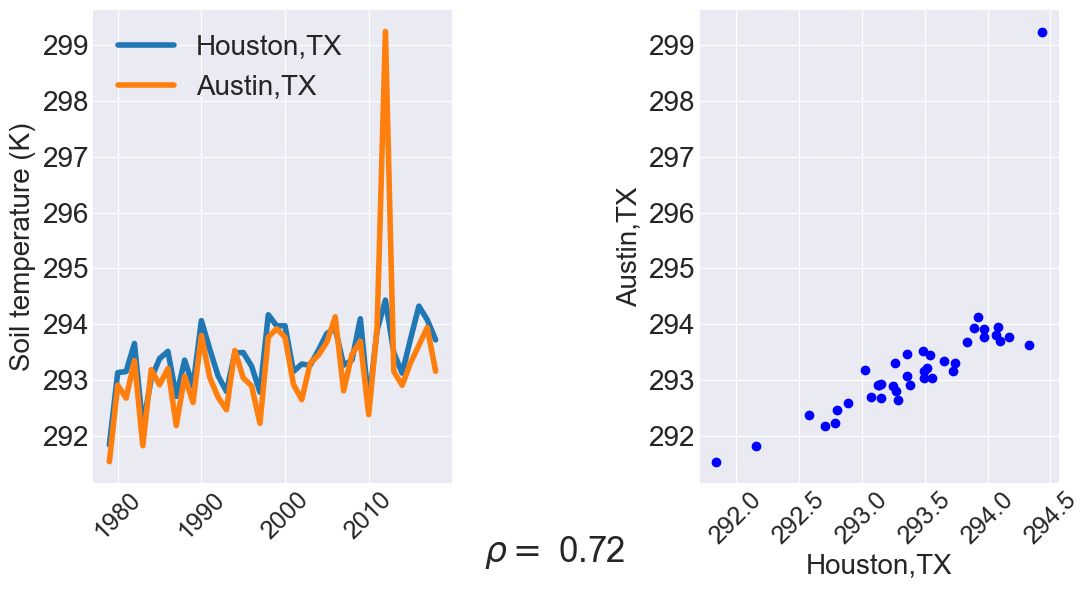

In [18]:
#Copy the data and add an outlier at index 33
tmp = np.copy(tsoil0_10cm_austin_annual)
tmp[33] = tmp[33] + 5
#Make some plots
plt.figure(figsize=(11,6))
plt.subplot(121)
plt.plot(np.arange(1979,2019),tsoil0_10cm_houston_annual,lw=4)
plt.plot(np.arange(1979,2019),tmp,lw=4)
#plt.title('Soil temperature (K)',fontsize=25)
plt.xticks(fontsize=18,rotation=45)
plt.yticks(fontsize=20)
plt.ylabel('Soil temperature (K)',fontsize=20)
plt.legend(['Houston,TX','Austin,TX'],fontsize=20)
plt.subplot(122)
plt.plot(tsoil0_10cm_houston_annual,tmp,'bo')
val = scipy.stats.pearsonr(tsoil0_10cm_houston_annual,tsoil0_10cm_austin_annual)[0]
print('Pearson correlation (Original): %.2f' %val)
val = scipy.stats.pearsonr(tsoil0_10cm_houston_annual,tmp)[0]
print('Pearson correlation (Modified): %.2f' %val)
plt.text(290,289.75,r'$\rho = $ %.2f' % val,fontsize=25)
#plt.title('Soil temperature (K)',fontsize=25)
plt.xticks(fontsize=18,rotation=45)
plt.yticks(fontsize=20)
plt.xlabel('Houston,TX',fontsize=20)
plt.ylabel('Austin,TX',fontsize=20)
plt.tight_layout()
plt.show()

Pearson correlations are notoriously sensitive to outliers in our data. A strong relationship between two series might exist, but an outlier throws off the signal when calculating the Pearson correlation. 

## Alternative I: Spearman rank correlation

The Spearman rank correlation is the Pearson correlation coefficient computed using the ranks of the data instead of the data itself. This ensures that outliers lose strength when comparing two series. 

The equation for calculating the Spearman rank correlation can be simplified to:

$$\rho_{rank} = 1 - \frac{6\sum_{i=1}^n D_i^2}{n(n^2-1)}$$

Where $D_i$ is the difference in ranks between the $i^{th}$ pair of data values. 

Source: Wilks, 2006

### Examples of Spearman vs Pearson (Source: Wikipedia)

<img src="https://upload.wikimedia.org/wikipedia/commons/thumb/4/4e/Spearman_fig1.svg/600px-Spearman_fig1.svg.png" width="400">

<img src="https://upload.wikimedia.org/wikipedia/commons/thumb/8/80/Spearman_fig2.svg/600px-Spearman_fig2.svg.png" width="400">

<img src="https://upload.wikimedia.org/wikipedia/commons/thumb/6/67/Spearman_fig3.svg/600px-Spearman_fig3.svg.png" width="400">

Let's revisit our outlier example

Spearman rank correlation (Original): 0.91
Spearman rank correlation (Modified): 0.91


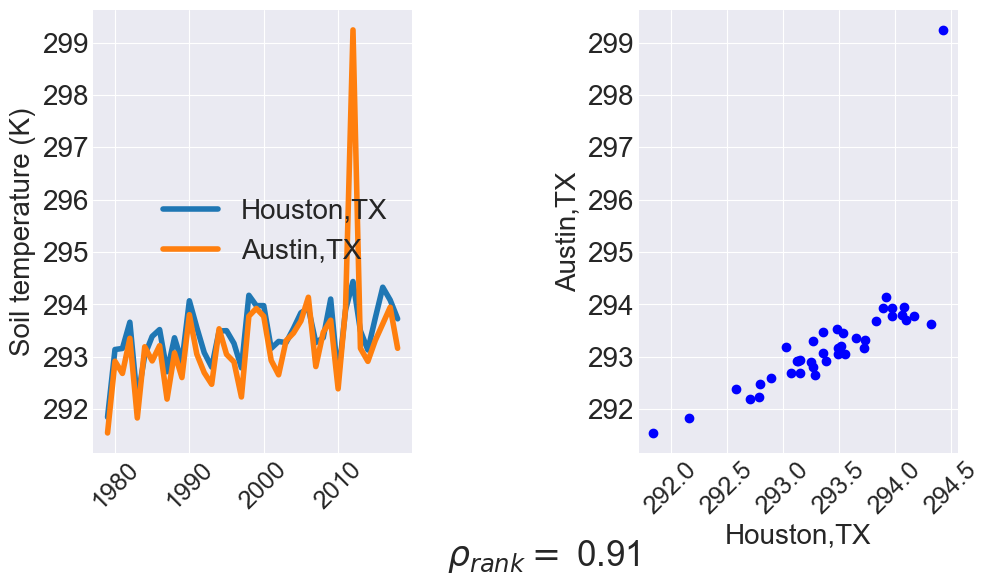

In [19]:
tmp = np.copy(tsoil0_10cm_austin_annual)
tmp[33] = tmp[33] + 5
#Make some plots
plt.figure(figsize=(10,6))
plt.subplot(121)
plt.plot(np.arange(1979,2019),tsoil0_10cm_houston_annual,lw=4)
plt.plot(np.arange(1979,2019),tmp,lw=4)
plt.xticks(fontsize=18,rotation=45)
plt.yticks(fontsize=20)
plt.ylabel('Soil temperature (K)',fontsize=20)
plt.legend(['Houston,TX','Austin,TX'],fontsize=20)
plt.subplot(122)
plt.plot(tsoil0_10cm_houston_annual,tmp,'bo')
rho_rank = scipy.stats.spearmanr(tsoil0_10cm_houston_annual,tsoil0_10cm_austin_annual)[0]
print('Spearman rank correlation (Original): %.2f' % rho_rank)
rho_rank = scipy.stats.spearmanr(tsoil0_10cm_houston_annual,tmp)[0]
print('Spearman rank correlation (Modified): %.2f' % rho_rank)
plt.text(290,289,r'$\rho_{rank} = $ %.2f' % rho_rank,fontsize=25)
plt.xticks(fontsize=18,rotation=45)
plt.yticks(fontsize=20)
plt.xlabel('Houston,TX',fontsize=20)
plt.ylabel('Austin,TX',fontsize=20)
plt.tight_layout()
plt.show()

## Alternative II: Kendall's $\tau$

Kendall's $\tau$ is calculated by considering the relationships among all possible mathcings of the data pairs ($x_i$,$y_i$), of which there are $n(n-1)/2$ in a sample of size $n$. 

Any matching in which both members of one pair are larger than their counterparts in the other pair is called concordant. 

For example, the pairs (3,8) and (7,83) would be concordant while the pairs (3,83) and (7,8) would be discordant). 

Kendall's $\tau$ is given by:

$$ \tau = \frac{N_C - N_D}{n(n-1)/2} $$

Where $N_C$ is the number of concordant pairs and $N_D$ is the number of discordant pairs.

Source: Wilks, 2006

Kendalls tau (Original): 0.74
Kendalls tau (Modified): 0.74


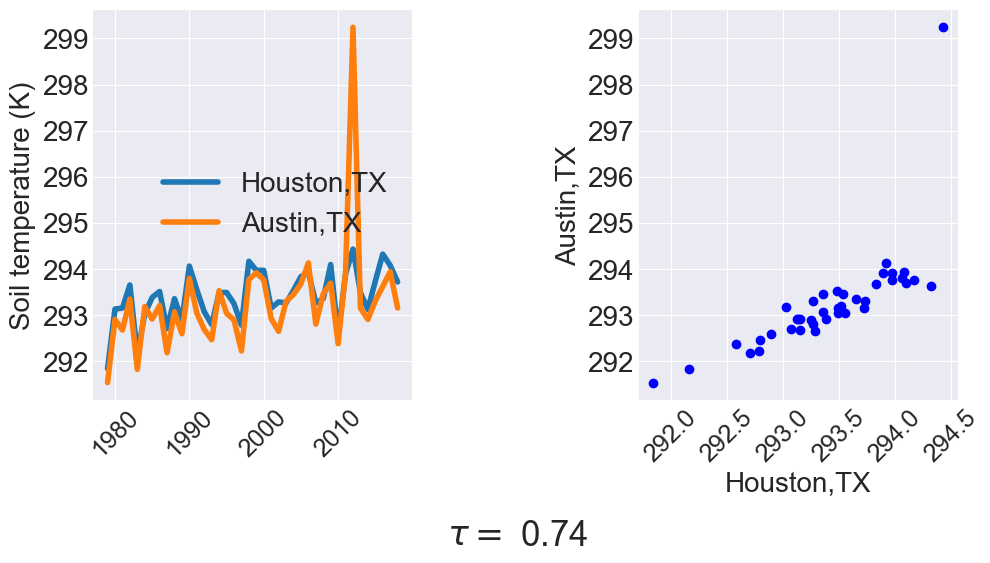

In [20]:
tmp = np.copy(tsoil0_10cm_austin_annual)
tmp[33] = tmp[33] + 5
#Make some plots
plt.figure(figsize=(10,6))
plt.subplot(121)
plt.plot(np.arange(1979,2019),tsoil0_10cm_houston_annual,lw=4)
plt.plot(np.arange(1979,2019),tmp,lw=4)
plt.xticks(fontsize=18,rotation=45)
plt.yticks(fontsize=20)
plt.ylabel('Soil temperature (K)',fontsize=20)
plt.legend(['Houston,TX','Austin,TX'],fontsize=20)
plt.subplot(122)
plt.plot(tsoil0_10cm_houston_annual,tmp,'bo')
rho_rank = scipy.stats.kendalltau(tsoil0_10cm_houston_annual,tsoil0_10cm_austin_annual)[0]
print(r'Kendalls tau (Original): %.2f' % rho_rank)
rho_rank = scipy.stats.kendalltau(tsoil0_10cm_houston_annual,tmp)[0]
print(r'Kendalls tau (Modified): %.2f' % rho_rank)
plt.text(290,288,r'$\tau = $ %.2f' % rho_rank,fontsize=25)
plt.xticks(fontsize=18,rotation=45)
plt.yticks(fontsize=20)
plt.xlabel('Houston,TX',fontsize=20)
plt.ylabel('Austin,TX',fontsize=20)
plt.tight_layout()
plt.show()

### Example: Compare the Contiguous United States to Houston

In [21]:
#Let's upscale NLDAS data to annual time step
tsoil0_10cm_conus_annual = []
imin = 0
imax = 12
for year in range(1979,2019):
    tsoil0_10cm_conus_annual.append(np.mean(tsoil0_10cm_conus[imin:imax,:,:],axis=0))
    imin = imin + 12
    imax = imax + 12
tsoil0_10cm_conus_annual = np.array(tsoil0_10cm_conus_annual)

In [22]:
#Compute the pearson correlation, spearman correlation, and Kendall's tau 
#between Houston's time series and all of the contiguous United States
def compute_correlation(data,data_point):
    output = {'kendall':np.zeros((data.shape[1],data.shape[2])),
              'pearson':np.zeros((data.shape[1],data.shape[2])),
              'spearman':np.zeros((data.shape[1],data.shape[2]))}
    for var in output:
        output[var][:] = -9999.0
    for i in range(data.shape[1]):
        for j in range(data.shape[2]):
            if data[0,i,j] < 0:
                continue
            output['pearson'][i,j] = scipy.stats.pearsonr(data[:,i,j],data_point)[0]
            output['spearman'][i,j] = scipy.stats.spearmanr(data[:,i,j],data_point)[0]
            output['kendall'][i,j] = scipy.stats.kendalltau(data[:,i,j],data_point)[0]
    return output

corrs = compute_correlation(tsoil0_10cm_conus_annual,tsoil0_10cm_houston_annual)

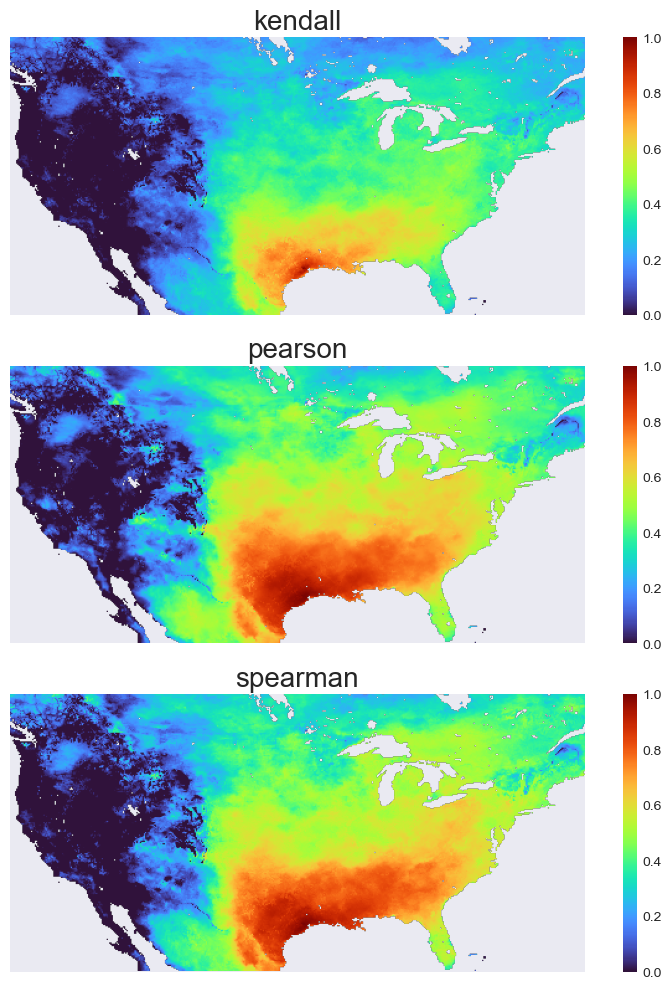

In [23]:
i = 0
plt.figure(figsize=(8,10))
for var in corrs:
    i+=1
    #Let's first mask out the undefined values (-9999)
    data = np.ma.masked_array(corrs[var],corrs[var]==-9999)
    #Now we will make the plot
    plt.subplot(3,1,i)
    plt.imshow(np.flipud(data),vmin=0,vmax=1,cmap='turbo')
    plt.title(var,fontsize=20)
    plt.xticks([])
    plt.yticks([])
    plt.colorbar()
plt.tight_layout()
plt.show()

## Correlation coefficients summary
* Pearson correlation reflects the strength of linear relationships
* Spearman rank correlation and Kendall's $\tau$ reflects the strength of monotone relationships
* Both the Spearman rank correlation and Kendall's $\tau$ are non-parametric; thus no assumption is made about the distribution of the data. 

In general, Kendall's $\tau$ is generally considered to be best; however, either choices are far superior to the Pearson correlation coefficient.

Note that the interpretability of the values of each metric cannot be truly compared to each other.

## Trend analysis

How do we quantify the apparent trend in the data?

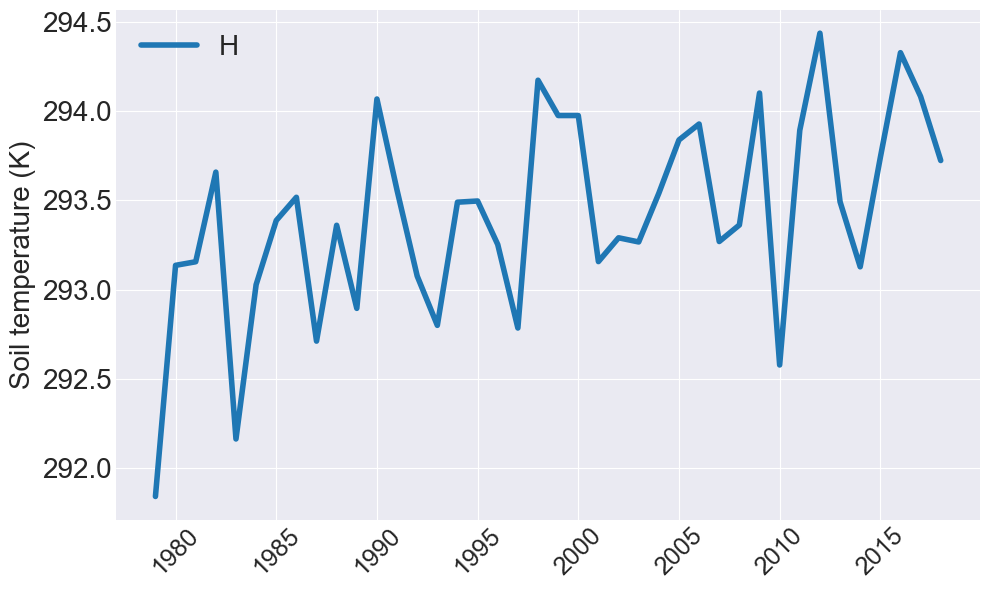

In [24]:
#Plot the annual time series of soil temperature
plt.figure(figsize=(10,6))
plt.plot(np.arange(1979,2019),tsoil0_10cm_houston_annual,lw=4)
plt.xticks(fontsize=18,rotation=45)
plt.yticks(fontsize=20)
plt.ylabel('Soil temperature (K)',fontsize=20)
plt.legend('Houston,TX',fontsize=20)
plt.tight_layout()
plt.show()

### Linear regression

<img src="https://bookdown.org/sbikienga/Intro_to_stat_book/images/chap7/ols.jpg" width="600">

Source: https://bookdown.org/sbikienga/Intro_to_stat_book

Let's fit a line to our data in Houston and plot the fitted line

In [25]:
years = np.arange(1979,2019)
(slope, intercept, r_value, p_value, std_err) = scipy.stats.linregress(years,tsoil0_10cm_houston_annual)
print('slope:',slope,'K/year')
print('intercept:',intercept,'K')

slope: 0.024742782048839118 K/year
intercept: 243.9674131125044 K


In [26]:
#Make the prediction
tpred = intercept + slope*years

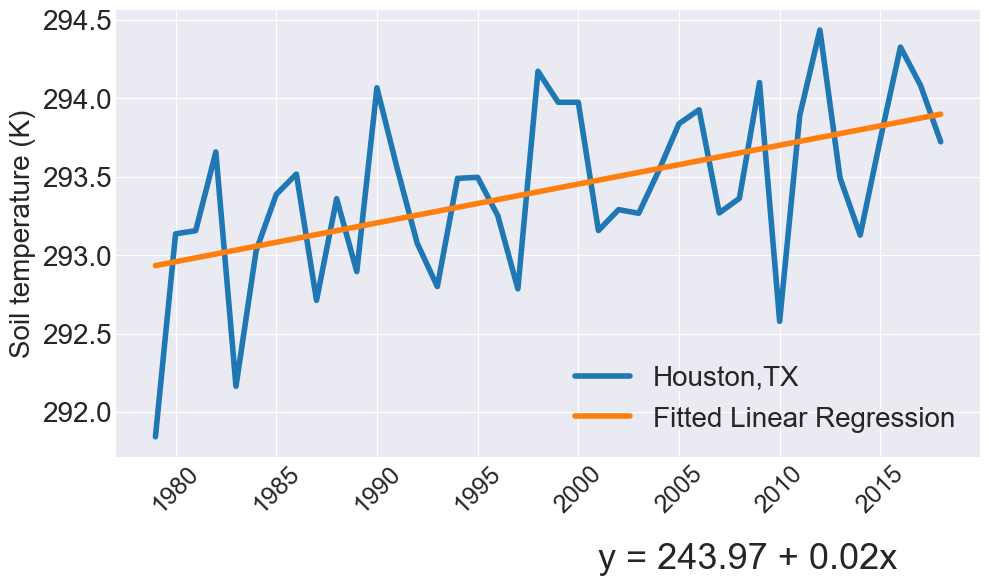

In [27]:
#Plot the annual time series of soil temperature and the prediction
plt.figure(figsize=(10,6))
plt.plot(years,tsoil0_10cm_houston_annual,lw=4)
plt.plot(years,tpred,lw=4)
plt.xticks(fontsize=18,rotation=45)
plt.yticks(fontsize=20)
plt.ylabel('Soil temperature (K)',fontsize=20)
plt.legend(['Houston,TX','Fitted Linear Regression'],fontsize=20)
plt.text(2001,291,'y = %.2f + %.2fx' % (intercept,slope),fontsize=26)
plt.tight_layout()
plt.show()

### Compute the linear trend over CONUS

In [28]:
#Compute the linear trend
def compute_linear_trend_simple_linear_regression(x,data):
    output = np.zeros((data.shape[1],data.shape[2]))
    #Initialize to undefined value of -9999
    output[:] = -9999.0
    for i in range(data.shape[1]):
        for j in range(data.shape[2]):
            if data[0,i,j] < 0:continue
            (slope, intercept, r_value, p_value, std_err) = scipy.stats.linregress(x,data[:,i,j])
            output[i,j] = slope
    return output

years = np.arange(1979,2019)
slope_slr = compute_linear_trend_simple_linear_regression(years,tsoil0_10cm_conus_annual)

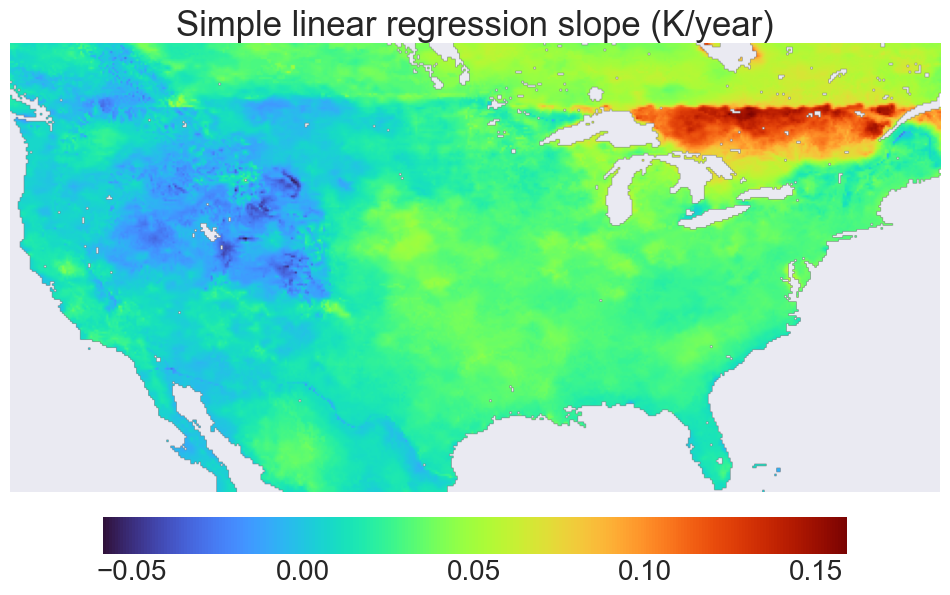

In [29]:
#Mask out -9999 values
slope_slr_masked = np.ma.masked_array(slope_slr,slope_slr==-9999)
plt.figure(figsize=(12,8))
plt.imshow(np.flipud(slope_slr_masked),cmap=plt.get_cmap('turbo'))
cb = plt.colorbar(orientation='horizontal',shrink=0.8,pad=0.04)
cb.ax.tick_params(labelsize=20)
plt.title('Simple linear regression slope (K/year)',fontsize=25)
plt.xticks([])
plt.yticks([])
plt.show()

The discontinuity between the USA and Canada is what happens when you combine meteorological data from two different countries to run your land surface model...

### Simple linear regression can lead to problems very quickly. 

Let's revisit the Houston example by introducing an outlier.

slope: 0.037406947152028615
intercept: 218.7830791537802


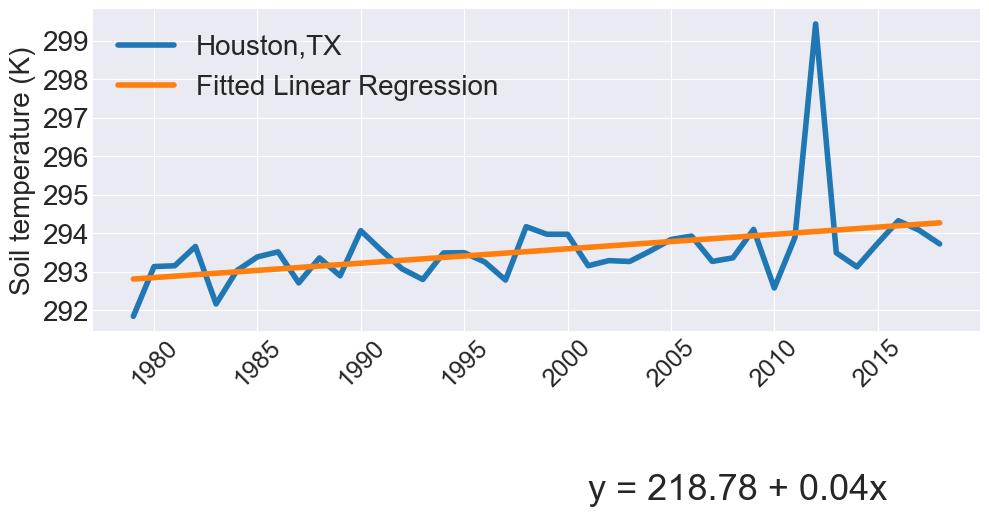

In [30]:
years = np.arange(1979,2019)
#Introduce an outlier
tsoil0_10cm_houston_annual_mod = np.copy(tsoil0_10cm_houston_annual)
tsoil0_10cm_houston_annual_mod[33] = tsoil0_10cm_houston_annual_mod[33] + 5
#Fit a line using simple linear regression
(slope, intercept, r_value, p_value, std_err) = scipy.stats.linregress(years,tsoil0_10cm_houston_annual_mod)
print('slope:',slope)
print('intercept:',intercept)
#Make the prediction
tpred = intercept + slope*years
#Plot the annual time series of soil temperature and the prediction
plt.figure(figsize=(10,6))
plt.plot(years,tsoil0_10cm_houston_annual_mod,lw=4)
plt.plot(years,tpred,lw=4)
plt.xticks(fontsize=18,rotation=45)
plt.yticks(fontsize=20)
plt.ylabel('Soil temperature (K)',fontsize=20)
plt.legend(['Houston,TX','Fitted Linear Regression'],fontsize=20)
plt.text(2001,287.1,'y = %.2f + %.2fx' % (intercept,slope),fontsize=26)
plt.tight_layout()
plt.show()

Outliers can strongly impact the calculated linear trend

### Alternative: Theil-Sen estimator

In non-parametric statistics, the Theil–Sen estimator is a method for robustly fitting a line to sample points in the plane (simple linear regression) by choosing the median of the slopes of all lines through pairs of points. 

Analogous to Kendall's $\tau$, we compute the slope of the line for each pair and then use the median of the computed slopes and intercepts as the final estimate of the slope and intercept. 

slope: 0.024543601588199015
intercept: 244.38755473086707


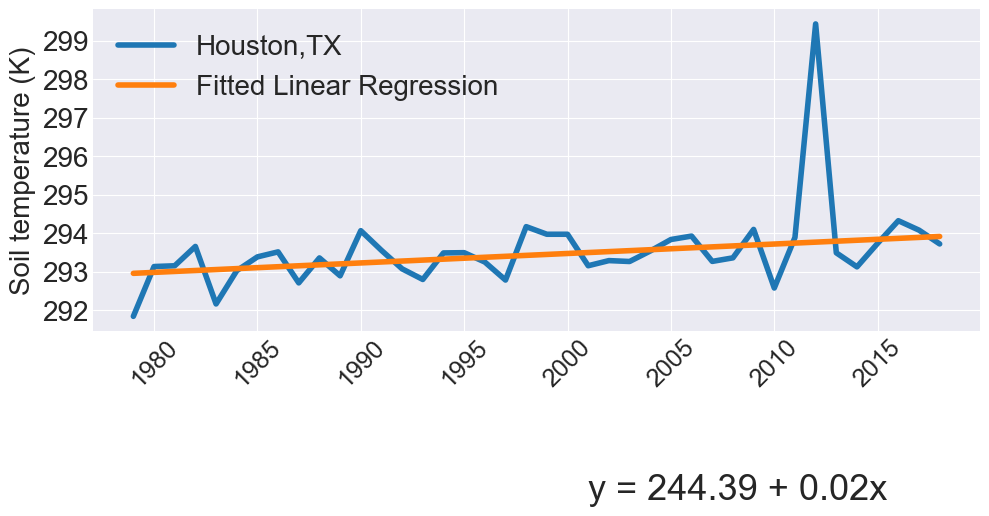

In [31]:
years = np.arange(1979,2019)
tsoil0_10cm_houston_annual_mod = np.copy(tsoil0_10cm_houston_annual)
tsoil0_10cm_houston_annual_mod[33] = tsoil0_10cm_houston_annual_mod[33] + 5
(slope, intercept, low_slope, high_slope) = scipy.stats.theilslopes(tsoil0_10cm_houston_annual_mod,years)
print('slope:',slope)
print('intercept:',intercept)
#Make the prediction
tpred = intercept + slope*years
#Plot the annual time series of soil temperature and the prediction
plt.figure(figsize=(10,6))
plt.plot(years,tsoil0_10cm_houston_annual_mod,lw=4)
plt.plot(years,tpred,lw=4)
plt.xticks(fontsize=18,rotation=45)
plt.yticks(fontsize=20)
plt.ylabel('Soil temperature (K)',fontsize=20)
plt.legend(['Houston,TX','Fitted Linear Regression'],fontsize=20)
plt.text(2001,287.1,'y = %.2f + %.2fx' % (intercept,slope),fontsize=26)
plt.tight_layout()
plt.show()

Let's compute the Theil-Sen estimator over CONUS

In [32]:
#Compute the linear trend
def compute_linear_trend_theil_sen(x,data):
    output = np.zeros((data.shape[1],data.shape[2]))
    #Initialize to undefined value of -9999
    output[:] = -9999.0
    for i in range(data.shape[1]):
        if i% 20 == 0:print('row:',i)
        for j in range(data.shape[2]):
            if data[0,i,j] < 0:
                continue
            (slope, intercept, low, high) = scipy.stats.theilslopes(data[:,i,j],x)
            output[i,j] = slope
    return output

years = np.arange(1979,2019)
slope_ts = compute_linear_trend_theil_sen(years,tsoil0_10cm_conus_annual)

row: 0
row: 20
row: 40
row: 60
row: 80
row: 100
row: 120
row: 140
row: 160
row: 180
row: 200
row: 220


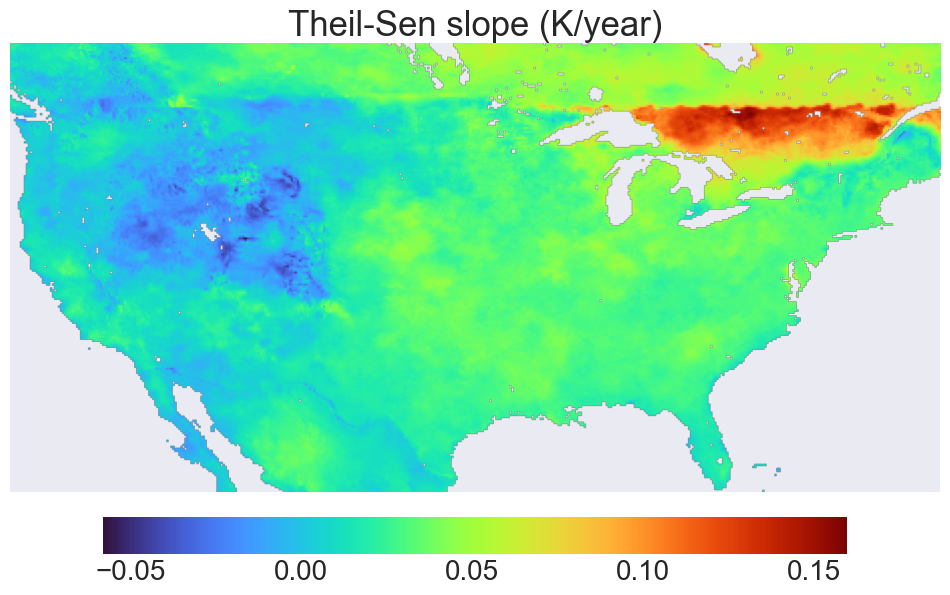

In [33]:
#Mask out -9999 values
slope_ts_masked = np.ma.masked_array(slope_ts,slope_ts==-9999)
plt.figure(figsize=(12,8))
plt.imshow(np.flipud(slope_ts_masked),cmap=plt.get_cmap('turbo'))
cb = plt.colorbar(orientation='horizontal',shrink=0.8,pad=0.04)
cb.ax.tick_params(labelsize=20)
plt.title('Theil-Sen slope (K/year)',fontsize=25)
plt.xticks([])
plt.yticks([])
plt.show()

Let's compare the map of slopes from simple linear regression with those from the Theil-Sen estimator

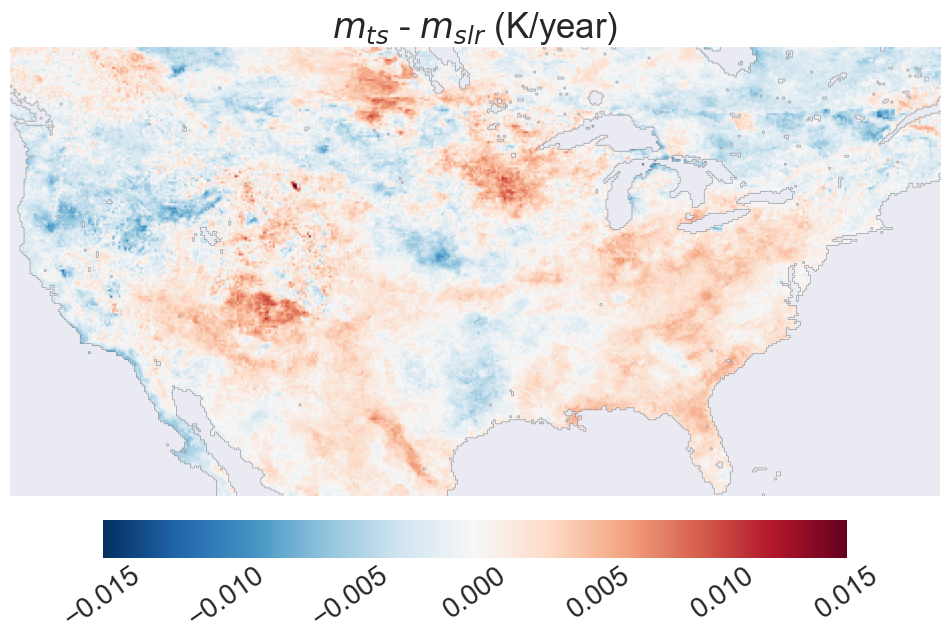

In [34]:
plt.figure(figsize=(12,8))
#Subtract the simple linear regression slopes from the theil-sen estimator slopes
slope_diff = slope_ts_masked - slope_slr_masked
plt.imshow(np.flipud(slope_diff),cmap=plt.get_cmap('RdBu_r'),vmin=-0.015,vmax=0.015)
cb = plt.colorbar(orientation='horizontal',shrink=0.8,pad=0.04)
cb.ax.tick_params(labelsize=20,rotation=35)
plt.title('$m_{ts}$ - $m_{slr}$ (K/year)',fontsize=25)
plt.xticks([])
plt.yticks([])
plt.show()

### Trend analysis conclusion: 
Although it requires more computation, when estimating linear trends, using the Sen-Theil approach (or other existing similarly robust approaches) is strongly encouraged over the use of simple linear regression.

## Applications of probability: Climate model bias correction

In [ ]:
#Read in ERA-Interim
import netCDF4 as nc
#Let's read in the annual mean temperature from ERA-Interim Reanalysis 
file = '/scratch/eeps440/data/era-interim/era_interim_monthly_197901_201512_upscaled.nc_ann'
fp = nc.Dataset(file)
output_era = {}
output_era['t_ref'] = 273.15 + fp['t2m'][:]
times = fp['time']
output_era['dates'] = nc.num2date(times[:],units=times.units,calendar=times.calendar,only_use_cftime_datetimes=False)
fp.close()

In [ ]:
#Let's read in the annual mean temperature from GFDL climate model simulations
output_gfdl = {}
file = '/scratch/eeps440/data/GFDL/atmos.1980-2014.t_ref.nc_ann'
fp = nc.Dataset(file)
output_gfdl['t_ref'] = fp['t_ref'][:]
times = fp['time']
output_gfdl['dates'] = nc.num2date(times[:],units=times.units,calendar=times.calendar,only_use_cftime_datetimes=False)
fp.close()

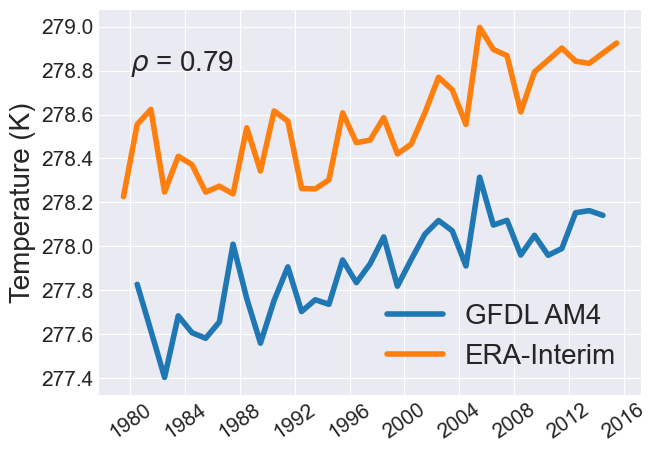

In [37]:
#Compute masks for slicing the same time period
dates_gfdl = output_gfdl['dates']
dates_era = output_era['dates']
m_gfdl = (dates_gfdl >= datetime.datetime(1980,1,1)) & (dates_gfdl <= datetime.datetime(2014,1,31))
m_era = (dates_era >= datetime.datetime(1980,1,1)) & (dates_era <= datetime.datetime(2014,1,31))

#Compare global time series
var = 't_ref'
fig = plt.figure(figsize=(7,5))
tref_am4 = np.mean(np.mean(output_gfdl[var],axis=1),axis=1)
tref_era = np.mean(np.mean(output_era[var],axis=1),axis=1)
plt.plot(output_gfdl['dates'],tref_am4,lw=4)
plt.plot(output_era['dates'],tref_era,lw=4)
plt.legend(['GFDL AM4','ERA-Interim'],fontsize=20)
plt.text(datetime.datetime(1980,1,1),278.8,
        r'$\rho$ = %.2f' % scipy.stats.pearsonr(tref_am4[m_gfdl],tref_era[m_era])[0],fontsize=20)
plt.ylabel('Temperature (K)',fontsize=20)
plt.xticks(fontsize=15,rotation=35)
plt.yticks(fontsize=15)
plt.grid('on')
plt.show()

The correlation is good, but there is a clear bias. How could we fix it?

Let's compare both the histogram and empirical CDF of both time series

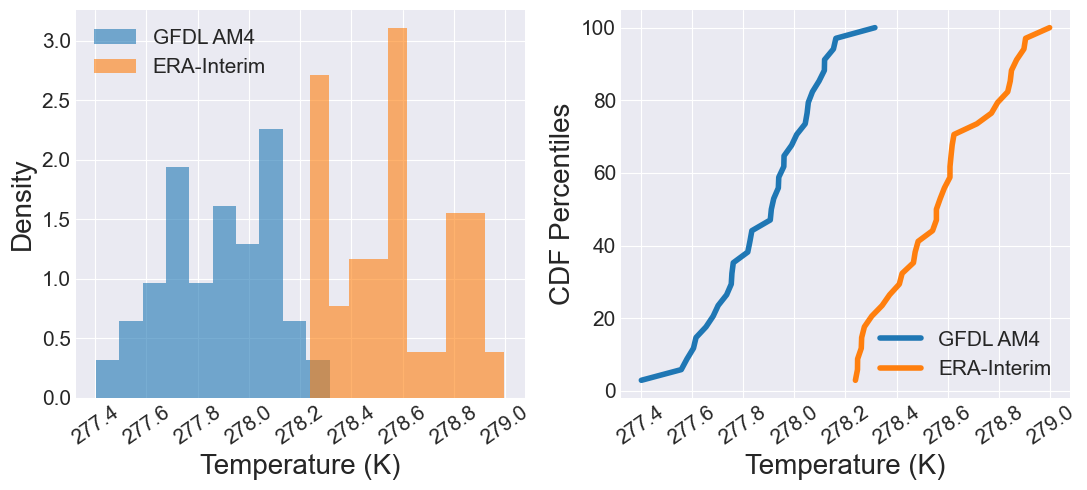

In [38]:
# Empirical cumulative distribution function 
def compute_ecdf(data):
    x = np.sort(data)
    n = x.size
    #Use weibull plotting positions
    y = 100*np.arange(1, n+1) / n
    return(x,y)

#Compare global time series
var = 't_ref'
fig = plt.figure(figsize=(11,5))
plt.subplot(121)
tref_am4 = np.mean(np.mean(output_gfdl[var],axis=1),axis=1)
tref_era = np.mean(np.mean(output_era[var],axis=1),axis=1)
tref_am4 = tref_am4[m_gfdl].compressed()
tref_era = tref_era[m_era].compressed()
plt.hist(tref_am4,bins=10,density=1,alpha=0.6)
plt.hist(tref_era,bins=10,density=1,alpha=0.6)
plt.xlabel('Temperature (K)',fontsize=20)
plt.ylabel('Density',fontsize=20)
plt.xticks(fontsize=15,rotation=35)
plt.yticks(fontsize=15)
plt.legend(['GFDL AM4','ERA-Interim'],fontsize=15)
plt.grid('on')
plt.subplot(122)
(scores_am4,pcts_am4) = compute_ecdf(tref_am4)
plt.plot(scores_am4,pcts_am4,lw=4)
(scores_era,pcts_era) = compute_ecdf(tref_era)
plt.plot(scores_era,pcts_era,lw=4)
plt.xlabel('Temperature (K)',fontsize=20)
plt.ylabel('CDF Percentiles',fontsize=20)
plt.xticks(fontsize=15,rotation=35)
plt.yticks(fontsize=15)
plt.legend(['GFDL AM4','ERA-Interim'],fontsize=15)
plt.grid('on')
plt.tight_layout()
plt.show()

If we want to correct the modeled temperature, what if we just match its distribution to that of the observations (i.e., ERA-Interim)?

# CDF matching

<img src="https://upload.wikimedia.org/wikipedia/commons/thumb/e/eb/Histogram_matching.PNG/440px-Histogram_matching.PNG" width="700">

CDF matching is as simple as having percentile $x$ of distribution 1 take the value of percentile $x$ of distribution 2. 

In [39]:
#This is a very crude function of how to do this. There are much more efficient ways
def cdf_match(vals1,vals2):
    #Here 1 is the distribution that will be matched to 2
    vals1_matched = []
    for i in range(vals1.size):
        # Extract the percentile for x1
        pct1 = scipy.stats.percentileofscore(vals1,vals1[i])
        # Extract the score the "correct cdf" at the given percentile
        vals1_matched.append(np.percentile(vals2,pct1,method='nearest'))
    return vals1_matched
        
tref_am4_corrected = cdf_match(tref_am4,tref_era)

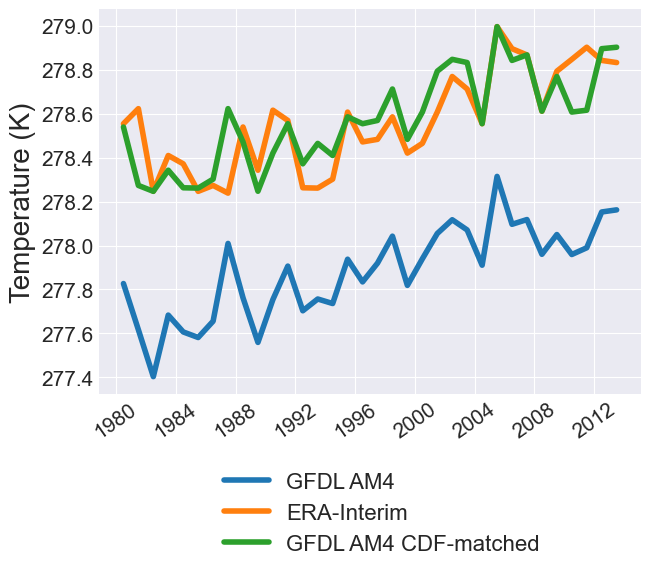

In [40]:
#Compare global time series
var = 't_ref'
fig = plt.figure(figsize=(7,5))
plt.plot(output_gfdl['dates'][m_gfdl],tref_am4,lw=4)
plt.plot(output_era['dates'][m_era],tref_era,lw=4)
plt.plot(output_era['dates'][m_era],tref_am4_corrected,lw=4)
plt.legend(['GFDL AM4','ERA-Interim','GFDL AM4 CDF-matched'],fontsize=16,bbox_to_anchor=(0.15, -0.65, 0.7, 0.5))
plt.ylabel('Temperature (K)',fontsize=20)
plt.xticks(fontsize=15,rotation=35)
plt.yticks(fontsize=15)
plt.grid('on')
plt.show()

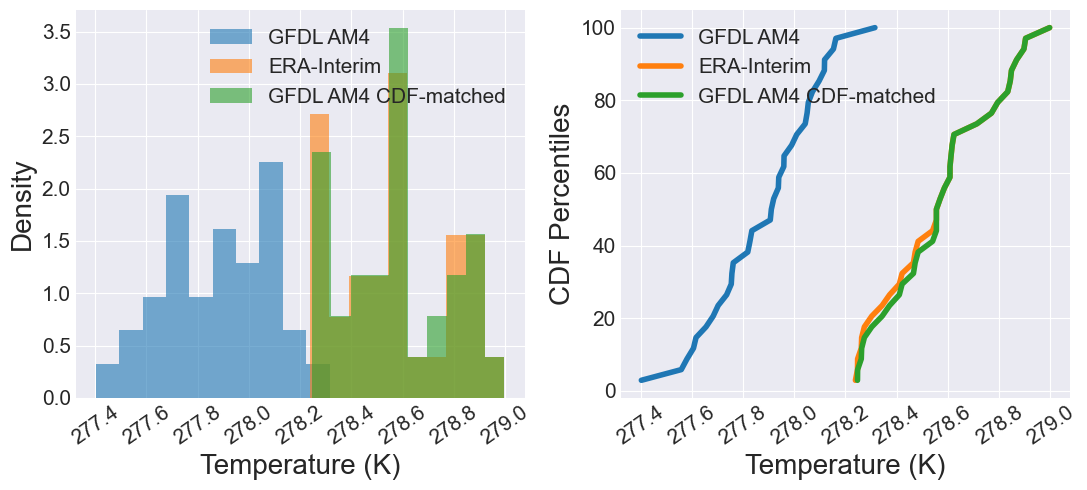

In [41]:
# Empirical cumulative distribution function 
def compute_ecdf(data):
    x = np.sort(data)
    n = x.size
    #Use weibull plotting positions
    y = 100*np.arange(1, n+1) / n
    return(x,y)

#Compare global time series
var = 't_ref'
fig = plt.figure(figsize=(11,5))
plt.subplot(121)
plt.hist(tref_am4,bins=10,density=1,alpha=0.6)
plt.hist(tref_era,bins=10,density=1,alpha=0.6)
plt.hist(tref_am4_corrected,bins=10,density=1,alpha=0.6)
plt.xlabel('Temperature (K)',fontsize=20)
plt.ylabel('Density',fontsize=20)
plt.xticks(fontsize=15,rotation=35)
plt.yticks(fontsize=15)
plt.legend(['GFDL AM4','ERA-Interim','GFDL AM4 CDF-matched'],fontsize=15)
plt.grid('on')
plt.subplot(122)
(scores_am4,pcts_am4) = compute_ecdf(tref_am4)
plt.plot(scores_am4,pcts_am4,lw=4)
(scores_era,pcts_era) = compute_ecdf(tref_era)
plt.plot(scores_era,pcts_era,lw=4)
(scores_am_correct,pcts_era) = compute_ecdf(tref_am4_corrected)
plt.plot(scores_am_correct,pcts_era,lw=4)
plt.xlabel('Temperature (K)',fontsize=20)
plt.ylabel('CDF Percentiles',fontsize=20)
plt.xticks(fontsize=15,rotation=35)
plt.yticks(fontsize=15)
plt.legend(['GFDL AM4','ERA-Interim','GFDL AM4 CDF-matched'],fontsize=15)
plt.grid('on')
plt.tight_layout()
plt.show()

It works but be very careful. You have to assume that the distribution does not change which is highly problematic if you assume a changing climate.